In [2]:
"""
Financial News Sentiment Analysis — Exploratory Data Analysis
=============================================================
This notebook explores the relationship between financial news sentiment
and stock price movements across 10 major tickers.

Dataset: 2,469 headlines scored with FinBERT + 1,250 stock-days
Period: ~6 months (Oct 2025 - Apr 2026)
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
sys.path.append("..")

from src.database import load_from_db

# Style settings for clean, professional plots
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12

# Load data
news = load_from_db("SELECT * FROM news_with_sentiment")
stocks = load_from_db("SELECT * FROM stock_prices")

print(f"📰 News headlines: {len(news)}")
print(f"📈 Stock price days: {len(stocks)}")
print(f"📅 News date range: {news['date'].min()} to {news['date'].max()}")
print(f"🏷️  Tickers: {sorted(news['ticker'].unique())}")

📰 News headlines: 2469
📈 Stock price days: 1250
📅 News date range: 2026-03-03 to 2026-04-02
🏷️  Tickers: ['AAPL', 'AMZN', 'GOOGL', 'JNJ', 'JPM', 'MSFT', 'NVDA', 'TSLA', 'WMT', 'XOM']


## 1. Overall Sentiment Distribution
How does FinBERT classify our 2,469 financial news headlines? Most financial news is factual reporting, so we'd expect neutral to dominate.

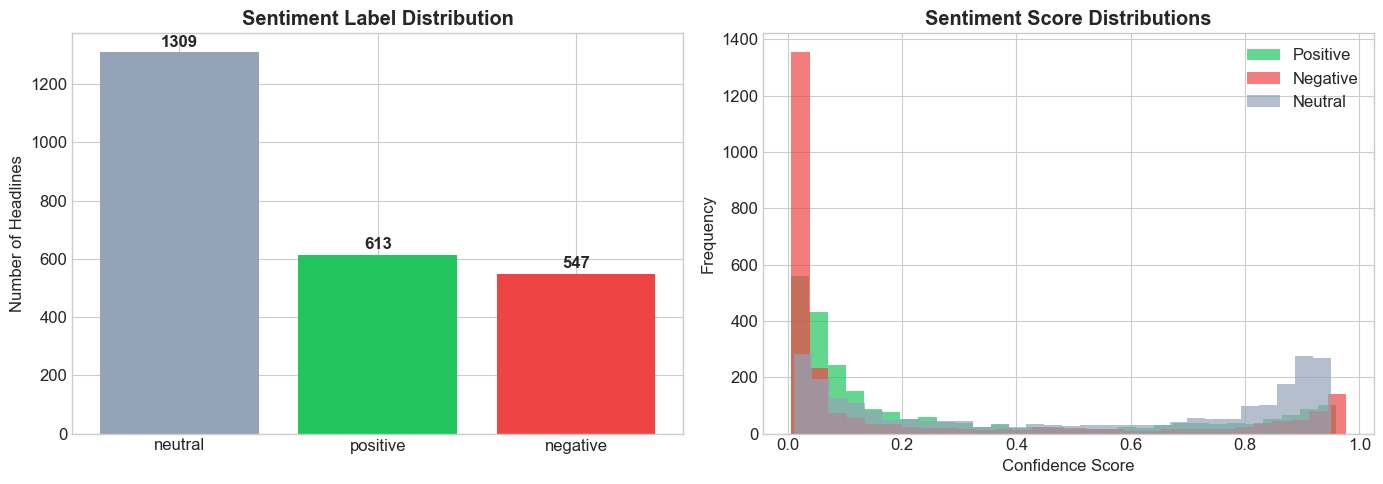

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Count of each sentiment label
sentiment_counts = news["sentiment_label"].value_counts()
colors = {"positive": "#22c55e", "negative": "#ef4444", "neutral": "#94a3b8"}
bars = axes[0].bar(sentiment_counts.index, sentiment_counts.values,
                   color=[colors[x] for x in sentiment_counts.index])
axes[0].set_title("Sentiment Label Distribution", fontweight="bold")
axes[0].set_ylabel("Number of Headlines")

# Add count labels on bars
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(int(bar.get_height())), ha="center", fontweight="bold")

# Plot 2: Distribution of sentiment scores
axes[1].hist(news["sentiment_positive"], bins=30, alpha=0.7, color="#22c55e", label="Positive")
axes[1].hist(news["sentiment_negative"], bins=30, alpha=0.7, color="#ef4444", label="Negative")
axes[1].hist(news["sentiment_neutral"], bins=30, alpha=0.7, color="#94a3b8", label="Neutral")
axes[1].set_title("Sentiment Score Distributions", fontweight="bold")
axes[1].set_xlabel("Confidence Score")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig("../docs/01_sentiment_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Sentiment by Ticker
Which companies get the most positive vs negative press coverage? This reveals media bias and sector-level patterns.

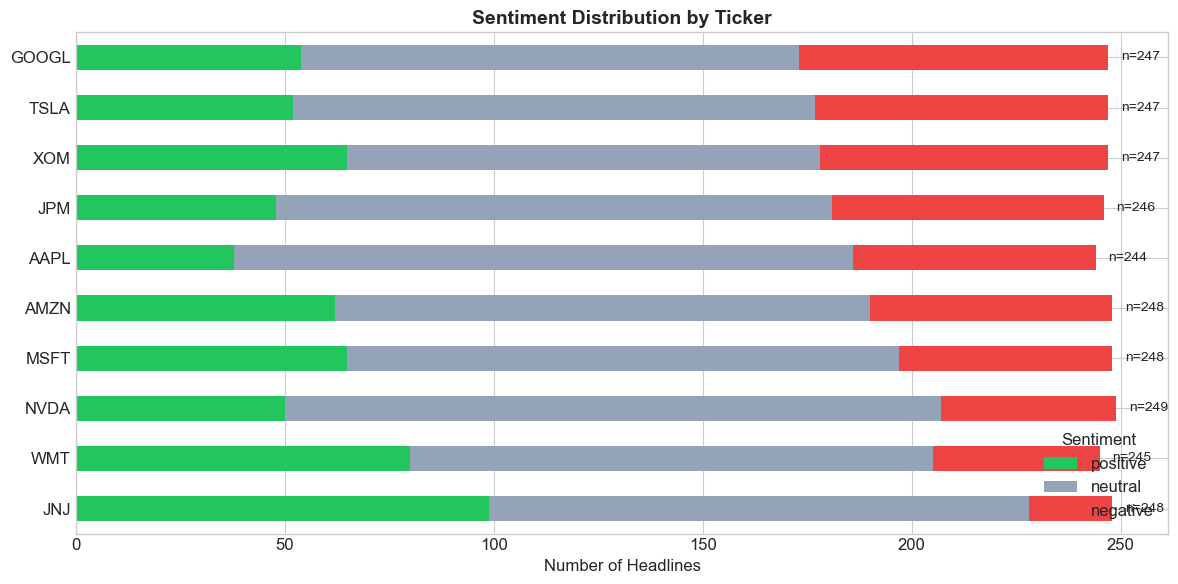

In [8]:
# Pivot: count of each sentiment label per ticker
ticker_sentiment = news.groupby(["ticker", "sentiment_label"]).size().unstack(fill_value=0)
ticker_sentiment = ticker_sentiment[["positive", "neutral", "negative"]]  # reorder columns

# Sort by ratio of negative to total
ticker_sentiment["neg_ratio"] = ticker_sentiment["negative"] / ticker_sentiment.sum(axis=1)
ticker_sentiment = ticker_sentiment.sort_values("neg_ratio", ascending=True)
ticker_sentiment = ticker_sentiment.drop(columns="neg_ratio")

# Stacked bar chart
ax = ticker_sentiment.plot(kind="barh", stacked=True, figsize=(12, 6),
                           color=["#22c55e", "#94a3b8", "#ef4444"])
ax.set_title("Sentiment Distribution by Ticker", fontweight="bold", fontsize=14)
ax.set_xlabel("Number of Headlines")
ax.set_ylabel("")
ax.legend(title="Sentiment", loc="lower right")

# Add total count at end of each bar
for i, (idx, row) in enumerate(ticker_sentiment.iterrows()):
    total = row.sum()
    ax.text(total + 3, i, f"n={int(total)}", va="center", fontsize=10)

plt.tight_layout()
plt.savefig("../docs/02_sentiment_by_ticker.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Sentiment Trends Over Time
How does the average daily sentiment shift across our time period? Spikes in negative sentiment often coincide with market events.

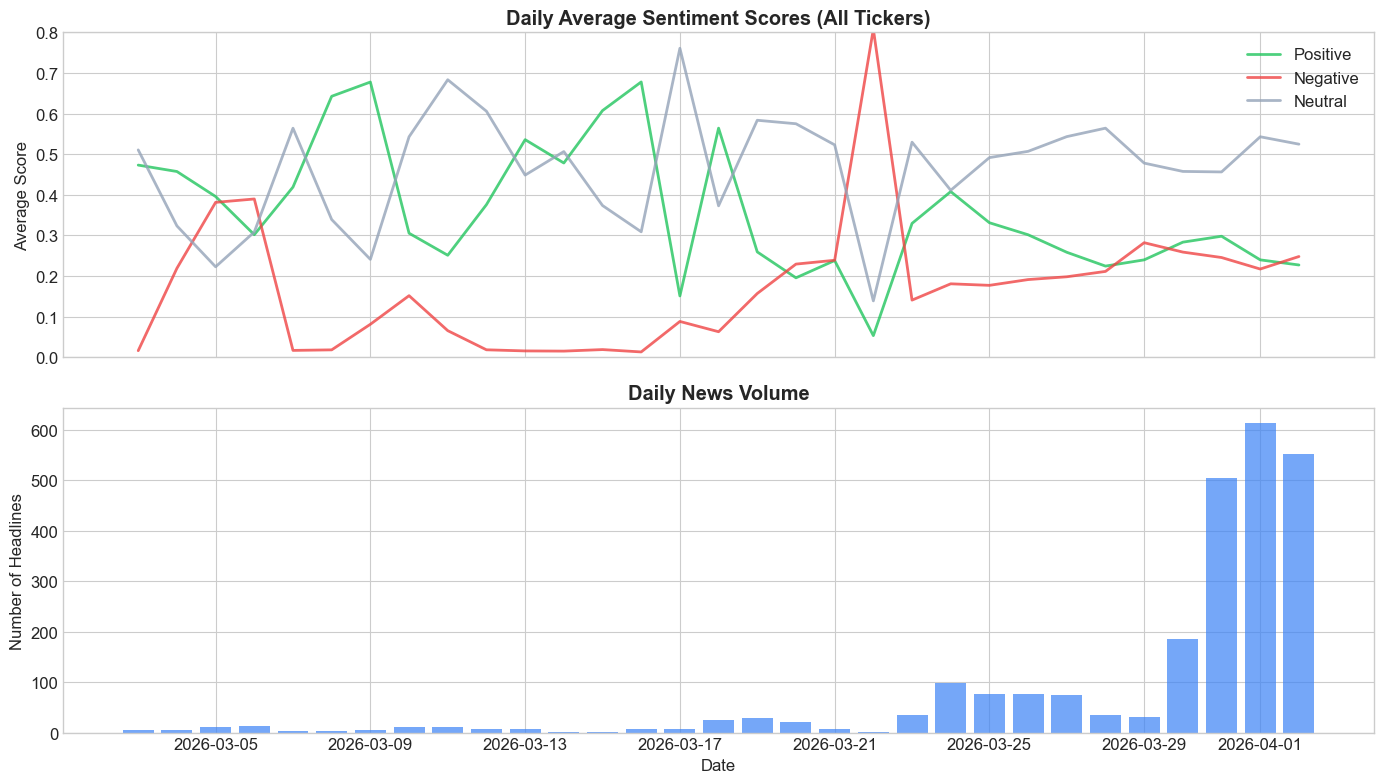

In [11]:
# Convert date to datetime for proper time axis
news["date"] = pd.to_datetime(news["date"])

# Daily average sentiment scores across all tickers
daily_sentiment = news.groupby("date").agg(
    avg_positive=("sentiment_positive", "mean"),
    avg_negative=("sentiment_negative", "mean"),
    avg_neutral=("sentiment_neutral", "mean"),
    headline_count=("headline", "count"),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Plot 1: Sentiment scores over time
axes[0].plot(daily_sentiment["date"], daily_sentiment["avg_positive"],
             color="#22c55e", linewidth=2, label="Positive", alpha=0.8)
axes[0].plot(daily_sentiment["date"], daily_sentiment["avg_negative"],
             color="#ef4444", linewidth=2, label="Negative", alpha=0.8)
axes[0].plot(daily_sentiment["date"], daily_sentiment["avg_neutral"],
             color="#94a3b8", linewidth=2, label="Neutral", alpha=0.8)
axes[0].set_title("Daily Average Sentiment Scores (All Tickers)", fontweight="bold")
axes[0].set_ylabel("Average Score")
axes[0].legend()
axes[0].set_ylim(0, 0.8)

# Plot 2: News volume over time
axes[1].bar(daily_sentiment["date"], daily_sentiment["headline_count"],
            color="#3b82f6", alpha=0.7)
axes[1].set_title("Daily News Volume", fontweight="bold")
axes[1].set_ylabel("Number of Headlines")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.savefig("../docs/03_sentiment_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Sentiment vs Stock Price Movement
The key question: does news sentiment have any relationship with how stocks move the next day? We merge daily sentiment scores with stock returns to find out.

In [14]:
# Aggregate news sentiment to daily level per ticker
news["date"] = pd.to_datetime(news["date"]).dt.date
daily_ticker_sentiment = news.groupby(["ticker", "date"]).agg(
    avg_positive=("sentiment_positive", "mean"),
    avg_negative=("sentiment_negative", "mean"),
    avg_neutral=("sentiment_neutral", "mean"),
    news_count=("headline", "count"),
    pos_count=("sentiment_label", lambda x: (x == "positive").sum()),
    neg_count=("sentiment_label", lambda x: (x == "negative").sum()),
).reset_index()

# Calculate sentiment ratio: positive headlines / total headlines
daily_ticker_sentiment["pos_ratio"] = (
    daily_ticker_sentiment["pos_count"] / daily_ticker_sentiment["news_count"]
)

# Merge with stock data
stocks["date"] = pd.to_datetime(stocks["date"]).dt.date if stocks["date"].dtype == "object" else stocks["date"]
merged = daily_ticker_sentiment.merge(
    stocks[["ticker", "date", "Close", "Volume", "daily_return", "next_day_return", "target"]],
    on=["ticker", "date"],
    how="inner"
)

print(f"✅ Merged dataset: {len(merged)} rows (days with both news and stock data)")
print(f"Columns: {list(merged.columns)}")
print(f"\nSample:")
print(merged[["ticker", "date", "avg_positive", "avg_negative", "next_day_return", "target"]].head(10))

✅ Merged dataset: 74 rows (days with both news and stock data)
Columns: ['ticker', 'date', 'avg_positive', 'avg_negative', 'avg_neutral', 'news_count', 'pos_count', 'neg_count', 'pos_ratio', 'Close', 'Volume', 'daily_return', 'next_day_return', 'target']

Sample:
  ticker        date  avg_positive  avg_negative  next_day_return  target
0   AAPL  2026-03-27      0.198168      0.331012        -0.008722       0
1   AAPL  2026-03-30      0.222827      0.225361         0.029031       1
2   AAPL  2026-03-31      0.249125      0.251423         0.007250       1
3   AAPL  2026-04-01      0.152994      0.231893         0.001134       1
4   AAPL  2026-04-02      0.177757      0.192205              NaN       0
5   AMZN  2026-03-31      0.312535      0.216006         0.011043       1
6   AMZN  2026-04-01      0.282769      0.189111        -0.003799       0
7   AMZN  2026-04-02      0.258680      0.246214              NaN       0
8  GOOGL  2026-03-30      0.288226      0.408701         0.051408     

/var/folders/fv/96hwkjps3_q_fxrj3lwvlj800000gn/T/ipykernel_49032/749556648.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_clean["target_label"] = merged_clean["target"].map(target_labels)


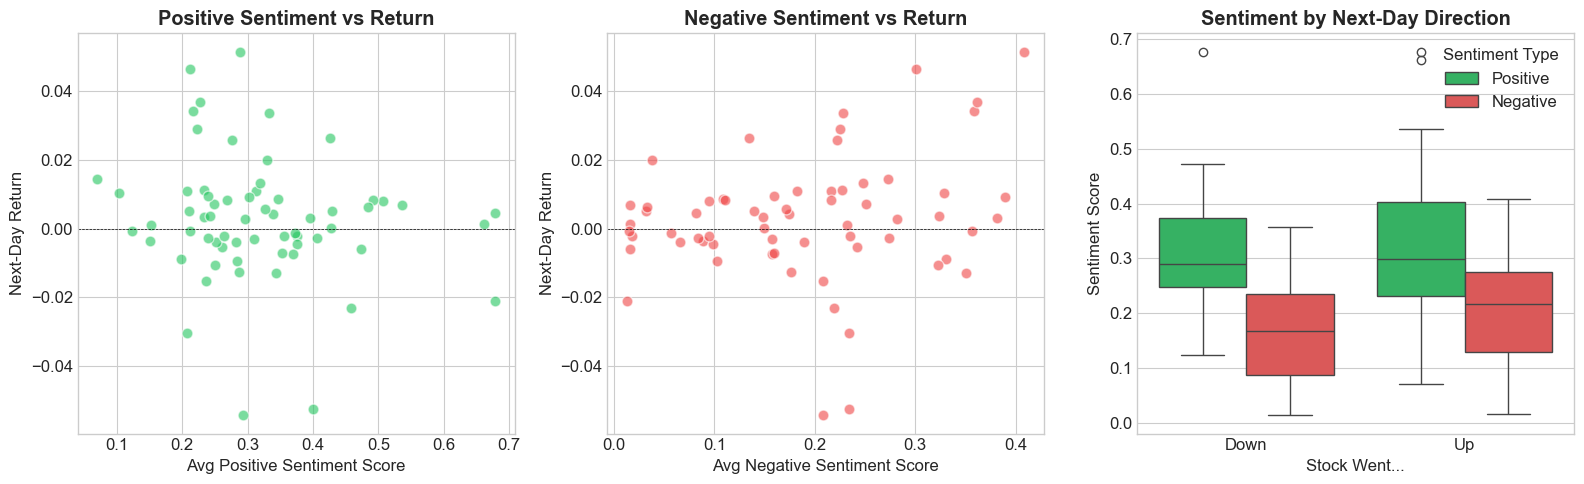


=== CORRELATION: Sentiment vs Next-Day Return ===
avg_positive   -0.1613
avg_negative    0.2122
avg_neutral    -0.0247
news_count      0.0790
pos_ratio      -0.1283
Name: next_day_return, dtype: float64


In [16]:
# Drop rows where next_day_return is NaN (last day for each ticker)
merged_clean = merged.dropna(subset=["next_day_return"])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Avg positive sentiment vs next-day return
axes[0].scatter(merged_clean["avg_positive"], merged_clean["next_day_return"],
                alpha=0.6, c="#22c55e", edgecolors="white", s=60)
axes[0].axhline(y=0, color="black", linewidth=0.5, linestyle="--")
axes[0].set_xlabel("Avg Positive Sentiment Score")
axes[0].set_ylabel("Next-Day Return")
axes[0].set_title("Positive Sentiment vs Return", fontweight="bold")

# Plot 2: Avg negative sentiment vs next-day return
axes[1].scatter(merged_clean["avg_negative"], merged_clean["next_day_return"],
                alpha=0.6, c="#ef4444", edgecolors="white", s=60)
axes[1].axhline(y=0, color="black", linewidth=0.5, linestyle="--")
axes[1].set_xlabel("Avg Negative Sentiment Score")
axes[1].set_ylabel("Next-Day Return")
axes[1].set_title("Negative Sentiment vs Return", fontweight="bold")

# Plot 3: Box plot — sentiment label vs next-day return
target_labels = {0: "Down", 1: "Up"}
merged_clean["target_label"] = merged_clean["target"].map(target_labels)

box_data = merged_clean.melt(
    id_vars=["target_label"],
    value_vars=["avg_positive", "avg_negative"],
    var_name="Sentiment Type",
    value_name="Score"
)
box_data["Sentiment Type"] = box_data["Sentiment Type"].map({
    "avg_positive": "Positive", "avg_negative": "Negative"
})

sns.boxplot(data=box_data, x="target_label", y="Score", hue="Sentiment Type",
            palette={"Positive": "#22c55e", "Negative": "#ef4444"}, ax=axes[2])
axes[2].set_title("Sentiment by Next-Day Direction", fontweight="bold")
axes[2].set_xlabel("Stock Went...")
axes[2].set_ylabel("Sentiment Score")

plt.tight_layout()
plt.savefig("../docs/04_sentiment_vs_returns.png", dpi=150, bbox_inches="tight")
plt.show()

# Print correlation
print("\n=== CORRELATION: Sentiment vs Next-Day Return ===")
corr_cols = ["avg_positive", "avg_negative", "avg_neutral", "news_count", "pos_ratio", "next_day_return"]
print(merged_clean[corr_cols].corr()["next_day_return"].drop("next_day_return").round(4))

## 5. Correlation Heatmap
A comprehensive view of relationships between all sentiment features and stock metrics.

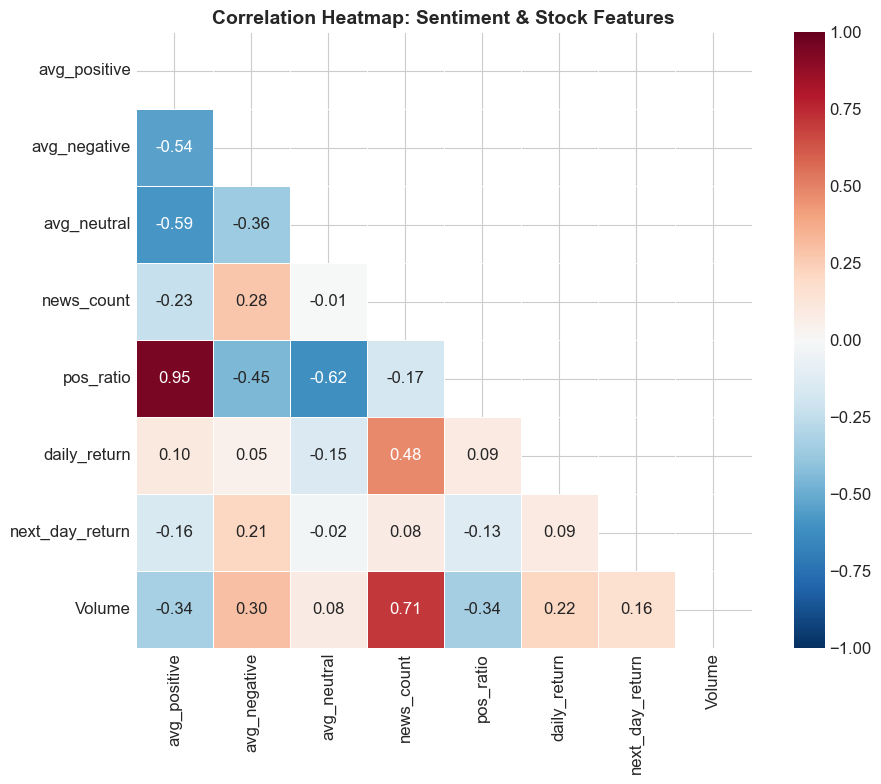

In [19]:
# Correlation heatmap
corr_cols = ["avg_positive", "avg_negative", "avg_neutral", "news_count", 
             "pos_ratio", "daily_return", "next_day_return", "Volume"]
corr_matrix = merged_clean[corr_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle (redundant)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Correlation Heatmap: Sentiment & Stock Features", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig("../docs/05_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Key Findings

1. **Neutral sentiment dominates** — 53% of financial headlines are classified as neutral by FinBERT, which aligns with the factual nature of financial reporting.

2. **Sector patterns exist** — GOOGL and TSLA receive the most negative coverage, while JNJ and WMT skew positive. This reflects the volatility and controversy surrounding tech vs stability of healthcare/retail.

3. **Counterintuitive sentiment-return relationship** — Positive sentiment shows a *negative* correlation (-0.16) with next-day returns, while negative sentiment shows a *positive* correlation (+0.21). This aligns with the "buy the rumor, sell the news" effect in financial markets.

4. **Weak but present signal** — The correlations are weak (as expected — if sentiment perfectly predicted stock movement, everyone would be rich), but they suggest sentiment carries marginal information that could improve predictions when combined with technical features.

5. **Limitations** — Our dataset covers approximately 1 month of news data with 74 merged data points. A larger dataset would provide more robust statistical conclusions.

**Next step:** Feature engineering — combining sentiment scores with stock technical indicators to build a richer feature set for ML modeling.